In [3]:
# training rough model

import numpy as np
from tensorflow.keras import layers, models
import tensorflow as tf
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [4]:
EPOCHS = 20
BATCH_SIZE = 4

X_DIR = "../data/processed/patches/X.npy"
Y_DIR = "../data/processed/patches/Y.npy"

X = np.load(X_DIR).astype(np.float32)
Y = np.load(Y_DIR).astype(np.float32)

print("X shape:", X.shape, "dtype:", X.dtype, "min/max:", X.min(), X.max())
print("Y shape:", Y.shape, "dtype:", Y.dtype, "min/max:", Y.min(), Y.max())

print("Foreground pixel ratio:", np.mean(Y))

X shape: (136, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
Y shape: (136, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
Foreground pixel ratio: 0.14651524


In [5]:
# simple unet model
# inputs → encoder → bottleneck → decoder → sigmoid mask

def build_unet(input_shape=(256,256,1)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b1 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    b1 = layers.Conv2D(64, 3, activation='relu', padding='same')(b1)

    # Decoder
    u1 = layers.UpSampling2D()(b1)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(c3)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    return model

In [6]:
# intensity augmentation to image only
# same geometric augmentation to image and mask
def augment_patch(image, mask):

    if random.random() < 0.5:
        image = np.flip(image, axis=1)
        mask = np.flip(mask, axis=1)

    if random.random() < 0.5:
        image = np.flip(image, axis=0)
        mask = np.flip(mask, axis=0)

    # 90 deg rotation
    k = random.choice([0, 1, 2, 3])
    image = np.rot90(image, k)
    mask = np.rot90(mask, k)

    # Brightness shift — image only
    if random.random() < 0.5:
        shift = random.uniform(-0.08, 0.08)
        image = image + shift

    # Contrast adjustment — image only
    if random.random() < 0.5:
        factor = random.uniform(0.85, 1.15)
        image = (image - image.mean()) * factor + image.mean()

    # Clip image back to valid range
    image = np.clip(image, 0, 1)

    # Ensure mask stays binary
    mask = (mask > 0.5).astype(np.float32)

    return image.astype(np.float32), mask.astype(np.float32)

In [7]:
def augment_dataset(X_train, Y_train, augment_factor=3):
    X_aug = [X_train]
    Y_aug = [Y_train]

    for _ in range(augment_factor):
        augmented_images = []
        augmented_masks = []

        for img, msk in zip(X_train, Y_train):
            img_aug, msk_aug = augment_patch(img, msk)
            augmented_images.append(img_aug)
            augmented_masks.append(msk_aug)

        X_aug.append(np.array(augmented_images, dtype=np.float32))
        Y_aug.append(np.array(augmented_masks, dtype=np.float32))

    X_aug = np.concatenate(X_aug, axis=0)
    Y_aug = np.concatenate(Y_aug, axis=0)

    return X_aug, Y_aug

In [8]:

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Before augmentation:")
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)

X_train_aug, Y_train_aug = augment_dataset(
    X_train,
    Y_train,
    augment_factor=3
)

print("\nAfter augmentation:")
print("X_train_aug:", X_train_aug.shape)
print("Y_train_aug:", Y_train_aug.shape)
print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)

Before augmentation:
X_train: (108, 256, 256, 1)
Y_train: (108, 256, 256, 1)
X_val: (28, 256, 256, 1)
Y_val: (28, 256, 256, 1)

After augmentation:
X_train_aug: (432, 256, 256, 1)
Y_train_aug: (432, 256, 256, 1)
X_val: (28, 256, 256, 1)
Y_val: (28, 256, 256, 1)


In [9]:

def dice_loss(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - ((2. * intersection + smooth) /
                (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth))

def weighted_bce(y_true, y_pred):
    y_pred = tf.clip_by_value(
        y_pred,
        tf.keras.backend.epsilon(),
        1 - tf.keras.backend.epsilon()
    )

    weights = y_true * 1.5 + 1
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)

    return tf.reduce_mean(weights * bce)

def combined_loss(y_true, y_pred):
    return weighted_bce(y_true, y_pred) + dice_loss(y_true, y_pred)

In [10]:
def weighted_bce(y_true, y_pred):
    y_pred = tf.clip_by_value(
        y_pred,
        tf.keras.backend.epsilon(),
        1 - tf.keras.backend.epsilon()
    )

    weights = y_true * 1.5 + 1
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)

    return tf.reduce_mean(weights * bce)

def combined_loss(y_true, y_pred):
    return weighted_bce(y_true, y_pred) + dice_loss(y_true, y_pred)

In [11]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def iou_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


In [12]:
model = build_unet()

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=combined_loss,
              metrics=[dice_coef, iou_coef])


In [13]:
history = model.fit(
    X_train_aug,
    Y_train_aug,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 26s 223ms/step - dice_coef: 0.2010 - iou_coef: 0.1129 - loss: 1.5692 - val_dice_coef: 0.2055 - val_iou_coef: 0.1157 - val_loss: 1.5724
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 24s 225ms/step - dice_coef: 0.1958 - iou_coef: 0.1099 - loss: 1.5568 - val_dice_coef: 0.1945 - val_iou_coef: 0.1087 - val_loss: 1.5748
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 236ms/step - dice_coef: 0.1957 - iou_coef: 0.1097 - loss: 1.5531 - val_dice_coef: 0.2006 - val_iou_coef: 0.1125 - val_loss: 1.5646
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 233ms/step - dice_coef: 0.1962 - iou_coef: 0.1099 - loss: 1.5517 - val_dice_coef: 0.1929 - val_iou_coef: 0.1077 - val_loss: 1.5746
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 233ms/step - dice_coef: 0.1953 - iou_coef: 0.1095 - loss: 1.5532 - val_dice_coef: 0.1958 - val_iou_coef: 0.1095 - val_loss: 1.5732
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 236ms/step - dice_coef: 0.1949 - iou_coef: 0.1090 - loss: 1.5543 - val_dice_coef:

In [14]:
preds_val = model.predict(X_val)

print("Prediction min:", preds_val.min())
print("Prediction max:", preds_val.max())
print("Prediction mean:", preds_val.mean())
print("Ground truth foreground ratio:", Y_val.mean())

def dice_at_threshold(y_true, y_pred, threshold):
    y_pred_bin = (y_pred > threshold).astype(np.float32)
    intersection = np.sum(y_true * y_pred_bin)
    return (2 * intersection + 1) / (np.sum(y_true) + np.sum(y_pred_bin) + 1)

for t in np.arange(0.25, 0.50, 0.025):
    d = dice_at_threshold(Y_val, preds_val, t)
    fg = (preds_val > t).mean()
    print(f"Threshold {t:.3f} | Dice: {d:.4f} | Pred foreground: {fg:.4f}")
    
# for t in [0.2, 0.3, 0.4, 0.5]:
#     print(f"Foreground ratio at threshold {t}:", (preds_val > t).mean())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 586ms/step
Prediction min: 0.14945959
Prediction max: 0.47106305
Prediction mean: 0.3104652
Ground truth foreground ratio: 0.15308926
Threshold 0.250 | Dice: 0.2654 | Pred foreground: 0.9813
Threshold 0.275 | Dice: 0.2627 | Pred foreground: 0.9394
Threshold 0.300 | Dice: 0.2478 | Pred foreground: 0.7885
Threshold 0.325 | Dice: 0.1500 | Pred foreground: 0.1637
Threshold 0.350 | Dice: 0.0207 | Pred foreground: 0.0115
Threshold 0.375 | Dice: 0.0115 | Pred foreground: 0.0060
Threshold 0.400 | Dice: 0.0006 | Pred foreground: 0.0007
Threshold 0.425 | Dice: 0.0002 | Pred foreground: 0.0003
Threshold 0.450 | Dice: 0.0000 | Pred foreground: 0.0000
Threshold 0.475 | Dice: 0.0000 | Pred foreground: 0.0000


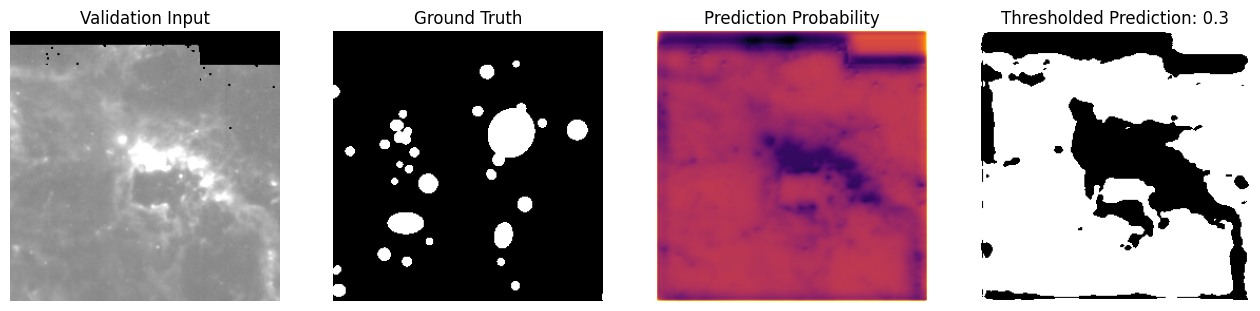

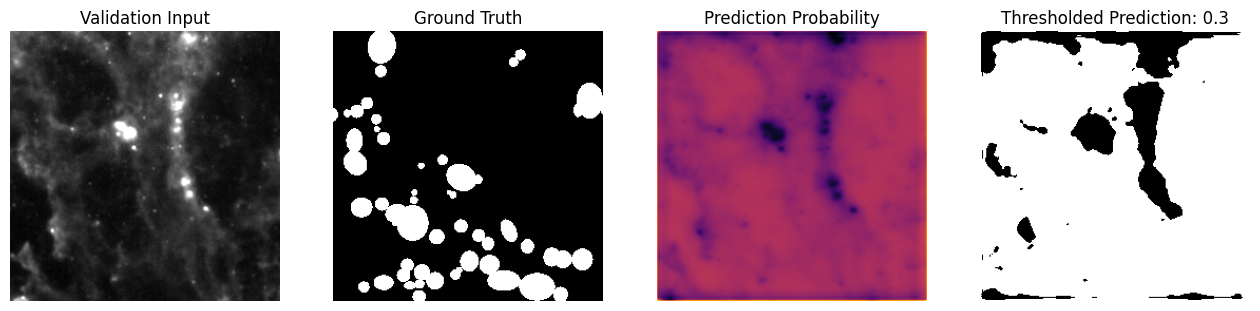

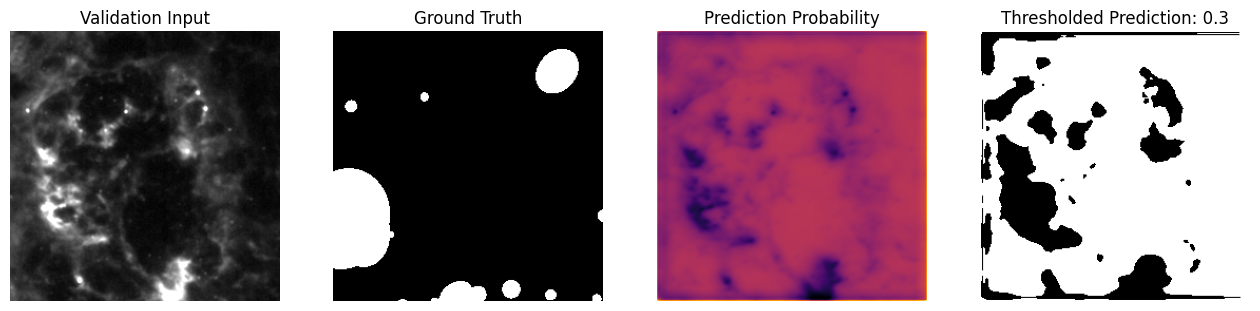

In [22]:
# idx = 0
pred = preds_val[idx].squeeze()
pred_thresh = (pred > 0.3).astype(np.float32)

for idx in [0, 5, 10]:

    plt.figure(figsize=(16, 4))
    
    plt.subplot(1, 4, 1)
    plt.imshow(X_val[idx].squeeze(), cmap="gray")
    plt.title("Validation Input")
    plt.axis("off")
    
    plt.subplot(1, 4, 2)
    plt.imshow(Y_val[idx].squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")
    
    plt.subplot(1, 4, 3)
    # plt.imshow(pred, cmap="inferno")
    plt.imshow(preds_val[idx].squeeze(), cmap="inferno")
    plt.title("Prediction Probability")
    plt.axis("off")
    
    plt.subplot(1, 4, 4)
    plt.imshow((preds_val[idx].squeeze() > 0.3).astype(np.float32), cmap="gray")
    plt.title("Thresholded Prediction: 0.3")
    plt.axis("off")
    
    plt.show()


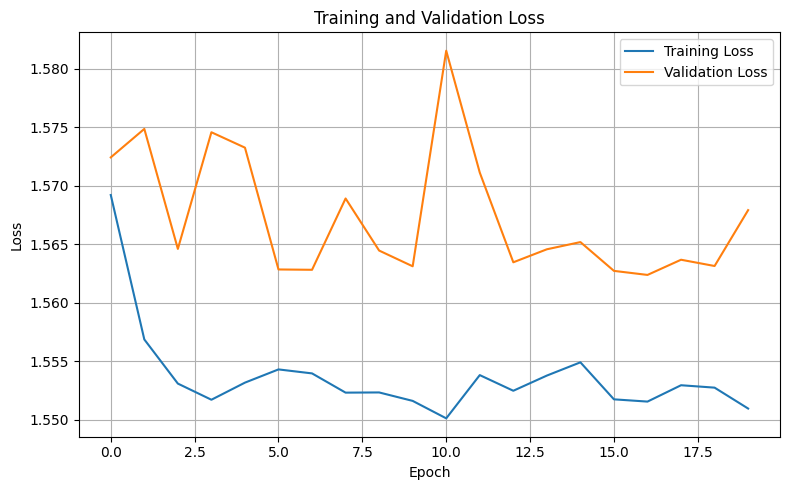

In [23]:
# Loss curves
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/figures/loss_curve.png', dpi=300)
plt.show()

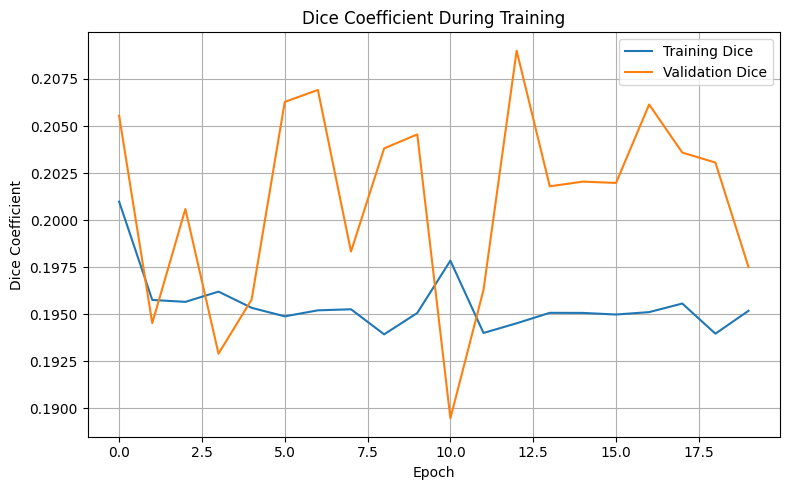

In [25]:
plt.figure(figsize=(8,5))
plt.plot(history.history['dice_coef'], label='Training Dice')
plt.plot(history.history['val_dice_coef'], label='Validation Dice')

plt.title('Dice Coefficient During Training')
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/figures/dice_curve.png', dpi=300)
plt.show()